# Exercise Sheet 4

## Part 1: Gaussian Process Regression with SK Learn

### Library Loading Block

In [123]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Thursday October 3, 2024

@authors: Elena Raponi, Kirill Antonov, Ivan Olarte-Rodriguez (partially inspired by Peter Frazier)

Revised on Thursday September 25, 2025

@revisors: Elena Raponi, Ivan Olarte-Rodriguez, Lennard Froma

"""

# Import the Libraries

# Typical Libraries for Numerical Processing
import numpy as np
from matplotlib import pyplot as plt

# Scikit Learn Libraries (For handling basic Regression Processes)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern,RBF, ConstantKernel as C
from typing import Callable
import pyDOE2

In the following block there are listed four different functions. Run this block in order to load the functions into the main module. These functions are then going to be switched to perform different approximations with the regressors.

In [124]:
def f(X:np.ndarray):
    # 1D example function to illustrate Gaussian process
    x = X.copy()
    return x * np.cos(x) + 10

def Ackley(x1:np.ndarray, x2:np.ndarray):
    # Usually evaluated on [-5,5]^2
    # Global minimum at (0, 0) where f(x1, x2) = 0
    return -20*np.exp(-0.2*np.sqrt(0.5*(x1**2+x2**2))) - np.exp(0.5*(np.cos(2*np.pi*x1)+np.cos(2*np.pi*x2))) + 20 + np.e

def Rosenbrock(x1:np.ndarray, x2:np.ndarray): 
    # Usually evaluated on [-2,2]^2
    # Global minimum at (a,a^2) where f(x1,x2)=0
    a = 1
    b = 100     
    return (a-x1)**2 + b*(x2 - x1**2)**2

def Sphere(x1:np.ndarray, x2:np.ndarray):
    # Can be evaluated on any search domain
    # Global minimum at (0,0) where f(x1,x2)=0
    return x1**2 + x2**2

Run the following block to plot the implementation of the interpolation

In [125]:
# define our known points and their measurements
# We start with a 1D simple example
# Sampling locations
xi = np.atleast_2d([-3., -1, 1.5, 2.5, 3]).T

# Sample observations
fi = f(xi).ravel()

# Some length scale
L= 1.0

The following block is a helper block to generate plotting functions. These are meant to plot the function, the prediction and the 95% confidence interval based on the mean squared error.

In [126]:
def plot_results_2d(X_obs, y_obs, x, y_pred, sigma):
    plt.figure()
    plt.plot(x, f(x), 'r:', label='$f(x) = x\ cos(x) + 10$')
    plt.plot(X_obs, y_obs, 'r.', markersize=10, label='Observations')
    plt.plot(x, y_pred, 'k-', label='Prediction')
    plt.fill(np.concatenate([x, x[::-1]]),
             np.concatenate([y_pred - 1.9600 * sigma,
                            (y_pred + 1.9600 * sigma)[::-1]]),
             alpha=.3, fc='k', label='95% confidence interval')
    plt.xlabel('$x$')
    plt.ylabel('$f(x)$')
    plt.ylim(0, 25)
    plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1))
    plt.show()
    
def plot_doe(x, lb = 0.0, ub = 1.0):
    num_samp = np.size(x,0)
    num_sampf = float(num_samp)
    fig = plt.figure()
    ax = fig.gca()
    ax.scatter(x[:,0],x[:,1])
    # --- boundaries of the design space
    ax.plot([0,0,1,1,0],[0,1,1,0,0], color=[0.5,0.5,0.5], linestyle='--', linewidth = 0.5)
    # --- grid lines  
    for i in range(num_samp):
        tmp = lb + (ub-lb)*i/num_sampf
        ax.plot([lb,ub],[tmp,tmp],color=[0.5,0.5,0.5], linestyle=':')
        ax.plot([tmp,tmp],[lb,ub],color=[0.5,0.5,0.5], linestyle=':')
        
    ax.set_xlim(lb,ub)
    ax.set_ylim(lb,ub)
    # -- labels
    ax.set_xlabel('x1', labelpad=8)
    ax.set_ylabel('x2', labelpad=8)
    plt.title('Optimal LH Samples', fontsize = 12)
    plt.axis('square')
    
def plot_results_3d(x1, x2, y_pred, x_samp=None, y_samp=None, lb=0.0, ub=1.0, title = '3D surface plot'):
    
    plt.figure(figsize=(15,10))

    fig,ax = plt.subplots(subplot_kw={"projection": "3d"})
    ax.plot_surface(x1, x2, y_pred, cmap='coolwarm', alpha = 0.6)
    if x_samp is not None:
        ax.scatter(x_samp[:,0], x_samp[:,1], y_samp, c='r', marker='x')
    ax.set_xlim(lb,ub)
    ax.set_ylim(lb,ub)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_zlabel('Obj. Function')
    ax.set_title(title)

### Exercise 1: Gaussian Process Regression (with Sci-kit Learn)
Fit the gaussian process regression (GPR) model using Scikit Learn's class `GaussianProcessRegressor`. Sample points and kernel definition are given. Define all the input parameters required by `plot_results_2d`.

In the following setting, the final model is obtained by using numerical optimization techniques to maximize the likelihood of the observed data, given our GPR model. Set the number of restarts for the optimizer to 10. Furthermore, in the following block you may find the definition of two kernels from `scikit-learn`, namely a composite kernel comprising a RBF and a constant kernel and a Matérn kernel. In addition to this, try changing the length scale.

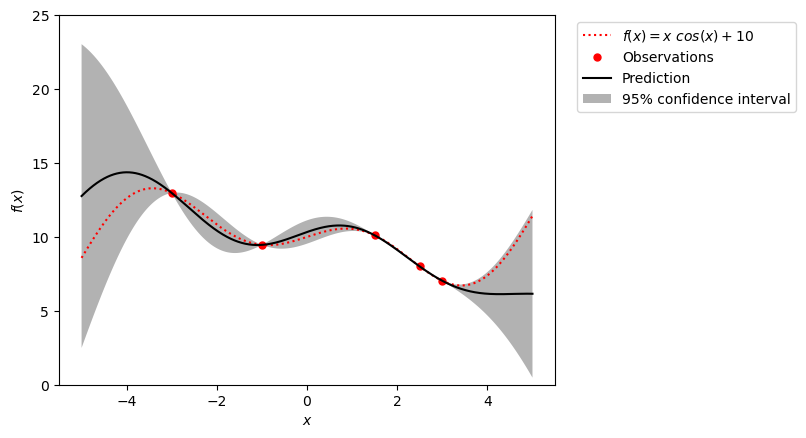

In [127]:
# We start with a 1D simple example
# Sampling locations
X:np.ndarray = xi.copy()

# Sample observations
y = fi.copy()

# Mesh the input space for evaluations of the real function, the prediction and confidence interval
x = np.atleast_2d(np.linspace(-5, 5, 1000)).T

# Initiate a Gaussian Process model
# RBF stands for Radial-basis function kernel (i.e. squared-exponential kernel
# Other available kernels include: C (for constant), WhiteKernel (for white noise), 
#                                  Matern, RationalQuadratic, ExpSineSquared (for a periodic kernel)
# See https://scikit-learn.org/stable/modules/gaussian_process.html#kernels-for-gaussian-processes
# for detailed documentation of all available kernels

##### TODO: In this part switch between the following defined kernels. Evaluate the results by switching each of them
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=L)
#kernel = Matern(length_scale=L,nu=2.5)

#####--------------- END OF SWITCH -----------------------

##### TODO: Enter your code here:

gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# Fit GPR model to observations (--> Maximum Likelihood Estimation)
gp.fit(X, y)

# Make the prediction on the meshed x-axis (ask for standard deviation as well)
y_pred, sigma = gp.predict(x, return_std=True)

##### --------------- END OF CODE INPUT -----------------------


plot_results_2d(X,y,x,y_pred,sigma)

### Exercise #2: Two-dimensional Gaussian Process Regression
Bring all your knowledge together and implement the whole process, from DoE to GPR regression, in this 2D example, i.e. we work with 2 variables and fit a response surface in a 3-dimensional space.

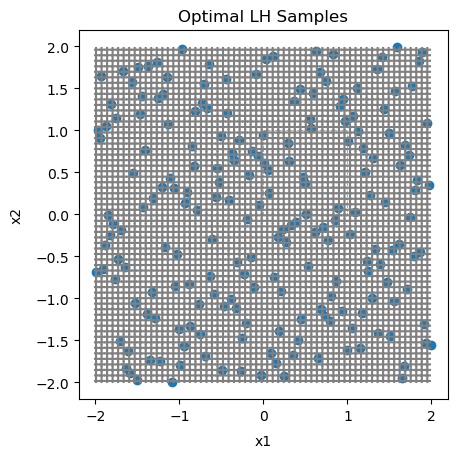

<Figure size 1500x1000 with 0 Axes>

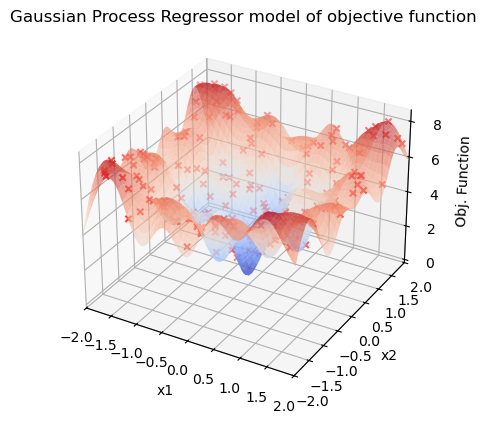

<Figure size 1500x1000 with 0 Axes>

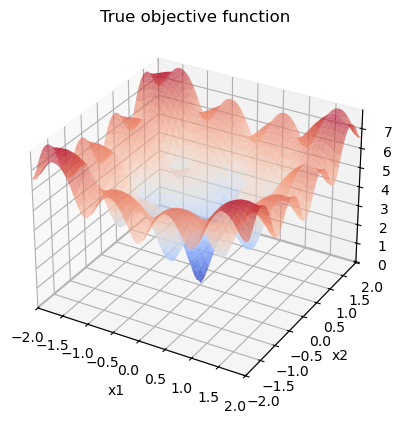

<Figure size 1500x1000 with 0 Axes>

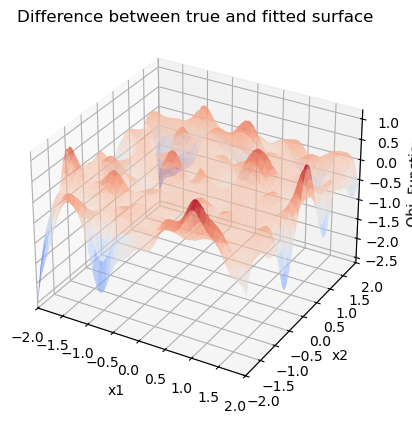

In [128]:
# Set parameters
g = Ackley # options are Sphere, Ackley, Rosenbrock
num_dv = 2
num_samp = 200  # Usually 10*[number of design variables] is a good rule of thumb
lb = -2
ub = 2

##### TODO: Enter your code here:

# Create samples using Optimal Latin Hypercube approach
x_samp = pyDOE2.lhs(num_dv, num_samp, criterion = 'centermaximin', iterations = 5000, random_state=42)
x_samp = lb + (ub-lb)*x_samp  # We have to map the generated samples back to our design space
plot_doe(x_samp, lb, ub)

# Calculate objective function values
y_samp = g(x_samp[:,0], x_samp[:,1])

#Initiate Gaussian Process model
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1, length_scale_bounds=(1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# Fit GPR model to observations (--> Maximum Likelihood Estimation)
gp.fit(x_samp, y_samp)

#Predict values on a meshed input space
x1_obs, x2_obs = np.meshgrid(np.linspace(lb,ub,100), np.linspace(lb,ub,100))
x_obs = np.array([np.reshape(x1_obs, (1,np.prod(x1_obs.shape)))[0], \
                    np.reshape(x2_obs, (1,np.prod(x2_obs.shape)))[0]]).T

y_pred = gp.predict(x_obs)
y_pred = np.reshape(y_pred, (100,100))

##### --------------- END OF CODE INPUT -----------------------

#Visualize results
plot_results_3d(x1_obs, x2_obs, y_pred, x_samp, y_samp, lb=lb, ub=ub,\
                title='Gaussian Process Regressor model of objective function')

#Also plot original function for comparison
plot_results_3d(x1_obs, x2_obs, g(x1_obs,x2_obs), lb=lb, ub=ub,\
                title='True objective function')

#Finally get the difference between original and fitted surface
plot_results_3d(x1_obs, x2_obs, y_pred - g(x1_obs,x2_obs), lb=lb, ub=ub,\
                title='Difference between true and fitted surface')

## Part 2: Setting up cases where there is no zero mean

### Exercise #3: Implement a Kernel Extension and predict functions
In the following blocks you're encouraged to generate your own tailormade Kernel and Predict functions. In the next block, you're encouraged to write a Matern Kernel yourself. For this, we will extend the abstract kernel definition found in `scikit-learn` (https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.kernels.Kernel.html#sklearn.gaussian_process.kernels.Kernel). In this setting a fixed member variable is needed, namely a `length scale` definition. On the other hand, the Matern Kernel requires parameters `nu` and `alpha_0`.

In the following block implement the `__call__` function. The steps are commented as a hint.

Specifically, the Matern Kernel is defined as:

$$K(x,x^{\prime}|\alpha_{0},\nu) = \alpha_{0} \frac{2^{1-\nu}}{\Gamma(\nu)} \left(  \sqrt{2 \nu} \ d(x,x^{\prime})   \right)^{\nu} J_{(\nu)} \left(  \sqrt{2 \nu} \ d(x,x^{\prime})    \right)$$

Where $d(x,x^{\prime})$ is a distance metric between two points in the parameter space. Given that the space is finite dimensional, then this distance is normally the Euclidean distance (or __2-norm__)factored by a length scale $L$ as:

$$ d(x,x^{\prime})  = \frac{||x - x^{\prime} ||_{2}}{L}$$

On the other hand $\Gamma(\nu)$ represents the Gamma function evaluated at $\nu$. This function is evaluated via `scipy.special.gamma`. $J_{(\nu)}$ is the modified Bessel function of the second kind parameterized by $\nu$. This is evaluated via the function `scipy.special.kv`.

In [111]:

from sklearn.gaussian_process.kernels import Kernel
from scipy.special import kv, gamma

class CustomMaternKernel(Kernel):
    def __init__(self, length_scale:float, nu:float=2.5, alpha_0:float = 1.0, epsilon:float=np.finfo(float).eps):
        ''' 
        This initialization requires the definition of and length scale (as default from Kernel framework)
        as well as the parameters of the Matern kernel (nu and alpha_0). In this case (to simplify the implementation)
        this kernel should be isotropic, meaning that the length scale is a scalar value 
        '''
        self.__length_scale:float = length_scale
        self.__nu:float = nu
        self.__alpha_0:float = alpha_0
        self.__epsilon:float = epsilon
        super().__init__()

        
    def __call__(self, x1:np.ndarray, x2:np.ndarray=None)->np.ndarray:
        ''' 
        The call function Requires x1 and x2 to each represent points in the parametric space. 
        The size of x1 should be (n1 x d) and x2 should be (n2 x d), where d stands for the dimensionality of the problem. 

        The output of this call function must be a n1 x n2 matrix. The matrix has the computation of kernel(x1[ii,:],x2[jj,:]), where ii in range(x1.shape[0]) 
        and jj in range(x2.shape[0])
        '''
        if x2 is None:
            x2 = x1.copy()
        
        if len(x1.shape)==1:
            x1 = np.expand_dims(x1,axis=1).reshape(-1,1)
        
        if len(x2.shape)==1:
            x2 = np.expand_dims(x2,axis=1).reshape(-1,1)

    
        matrix = np.zeros((x1.shape[0],x2.shape[0]))

        ##### TODO: Enter your code here:
        for ii in range(matrix.shape[0]):
            for jj in range(matrix.shape[1]):

                # =========Compute the variable r: ==========================
                # r is the Euclidean distance between x1 and x2,
                # after we normalize each dimension by the length scale
                r = np.divide(np.linalg.norm(x1[ii,:]-x2[jj,:]),self.length_scale)


                # ========= Adjust the case when r=0: ==========================
                # When r is 0 (which causes tmp to be 0),
                # the code below returns nan because tmp**nu is 0 but kv(nu,tmp) is infinite.
                # We fix this by adding a small amount to r in this situation.
                # We could have also fixed this by simply returning alpha0,
                # which is the correct covariance when r=0.
                if r==0.:
                    r += self.epsilon

                # ========= Compute the formula for the Matern Kernel: ==========================
                tmp =   np.sqrt(2*self.nu)*r
                matrix[ii,jj] = self.alpha_0 * self.c * tmp**self.nu * kv(self.nu, tmp)

        ##### --------------- END OF CODE INPUT -----------------------

        return matrix 

    
        
    ### These are methods required by the implementation
    def diag(self, X:np.ndarray):
        if len(X.shape)==1:
            np.expand_dims(X,axis=1)
            
        r = np.zeros(X.shape[0]) + self.epsilon
        
        tmp =   np.sqrt(2*self.__nu)*r
        return self.__alpha_0 * self.c * tmp**self.__nu * kv(self.__nu, tmp)

    def is_stationary(self):
        return True
    
    @property
    def alpha_0(self)->float:
        return self.__alpha_0
    
    @property
    def nu(self)->float:
        return self.__nu
    
    @property
    def length_scale(self)->float:
        return self.__length_scale
    
    @alpha_0.setter
    def alpha_0(self,new_alpha_0:float)->None:
        self.__alpha_0 = new_alpha_0

    @nu.setter
    def nu(self,new_nu:float)->None:
        self.__nu = new_nu

    @length_scale.setter
    def length_scale(self,new_length_scale:float)->None:
        self.__length_scale = new_length_scale
    
    @property
    def c(self)->float:
        return   2**(1-self.__nu) / gamma(self.__nu)
    
    @property
    def epsilon(self)->float:
        return self.__epsilon
    
    @epsilon.setter
    def epsilon(self,new_epsilon:float)->None:
        assert new_epsilon>0, "Epsilon must be a positive value"
        self.__epsilon = new_epsilon
    

# Call an instance of your customized kernel
kernel = CustomMaternKernel(length_scale=L,alpha_0=1.0,nu=2.5)
kernel_def = Matern(length_scale=L,nu=2.5)
# Print a computation
X = np.array([[1], [2], [3], [4]])
X2 = np.array([[2], [3], [4], [5]])
print("Hard Coded Kernel: ", kernel(X,X2))
print("Default Matern Kernel: ", kernel_def(X,X2))

Hard Coded Kernel:  [[0.52399411 0.13866022 0.02772342 0.00477708]
 [1.         0.52399411 0.13866022 0.02772342]
 [0.52399411 1.         0.52399411 0.13866022]
 [0.13866022 0.52399411 1.         0.52399411]]
Default Matern Kernel:  [[0.52399411 0.13866022 0.02772342 0.00477708]
 [1.         0.52399411 0.13866022 0.02772342]
 [0.52399411 1.         0.52399411 0.13866022]
 [0.13866022 0.52399411 1.         0.52399411]]


Now run the following block to test your customized Kernel.

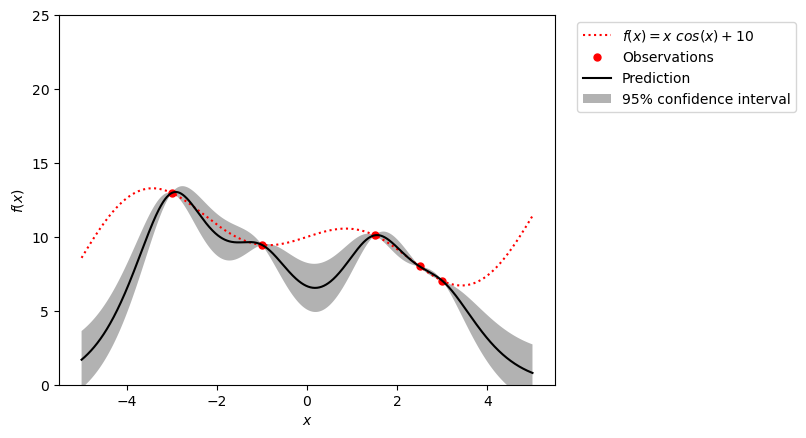

In [98]:
# We start with a 1D simple example
# Sampling locations
X:np.ndarray = xi.copy().reshape((-1, 1))


# Sample observations
y = fi.copy().reshape((-1, 1))

# Mesh the input space for evaluations of the real function, the prediction and confidence interval
x = np.atleast_2d(np.linspace(-5, 5, 1000)).reshape((-1, 1))

# Initiate a Gaussian Process model
kernel = CustomMaternKernel(length_scale=L,nu=2.5, alpha_0=1.0)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# Fit GPR model to observations (--> Maximum Likelihood Estimation)
gp.fit(X, y)

# Make the prediction on the meshed x-axis (ask for standard deviation as well)
y_pred, sigma = gp.predict(x, return_std=True)


plot_results_2d(X,y,x,y_pred,sigma)

Now it's turn to call a customized `fit_predict` function. Write a function that calculates the mean and variance of the 
posterior distribution at a point test_x. Your function should 
return the result as a list, where the first entry  is the posterior mean
and the second is the posterior variance.  You may find that because of 
numerical imprecision, the posterior variance can be slightly negative.

The mean and variance of the posterior distribution are defined as:
\begin{align}
f(x) &\mid f(x_{1:n}) \sim \mathrm{Normal}(\mu_n(x),\sigma^2_n(x))\\
\mu_n(x) &= \Sigma_0(x,x_{1:n}) \Sigma_0(x_{1:n},x_{1:n})^{-1} (f(x_{1:n})-\mu_0(x_{1:n})) + \mu_0(x) \\
\sigma^2_n(x) &= \Sigma_0(x,x) - \Sigma_0(x,x_{1:n}) \Sigma_0(x_{1:n},x_{1:n})^{-1} \Sigma_0(x_{1:n},x)
\end{align}


For the solution we suggest two linear algebra functions from numpy:
- numpy.linalg.inv: https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html
- numpy.matmul: https://numpy.org/doc/stable/reference/generated/numpy.matmul.html

*Hint 1*: The formula in the BayesOpt tutorial has the expression,
$\Sigma_0(x_{1:n},x)$
which is a short way of writing the column vector,
$[\Sigma_0(x_1,x), \ldots, \Sigma_0(x_n,x)]^T$.

Suppose we have python code where:
* $\Sigma_0$ is computed by the function `kernel`
* $x_{1:n}$ is stored in the list `train_x`
* We have another point `x`

So then the row vector $\Sigma_0(x_{1:n},x)$ we want to construct is:

    [kernel(train_x[0],x),..., kernel(train_x[n-1],x))]

A quick way to construct this row vector as a list is 

    [kernel(y,x) for y in train_x]

*Hint 2:* You can convert a list of numbers to a numpy array. This allows for matrix multiplication, taking the transpose, and adding a subtracting scalars.

In [99]:
# This defines a mean function that evaluates to 0 for all inputs 
mean0 = lambda x : 0.0
kern = CustomMaternKernel(length_scale=L,alpha_0=1.0,nu=2.5)


def fit_predict(test_x, train_x, train_y, mean = mean0, kernel:Kernel=CustomMaternKernel(length_scale=1.0,alpha_0=1.0,nu=2.5)):
    # Inputs:
    # test_x is a point in the x space
    # train_x is an array of points
    # train_y is an array equal in length to train_x, giving the value of our observation at each point
    # mean and kernel are two functions
    # mean should take one point as input, mean(x)
    # kernel should take two points as input, kernel(x,xprime)
    
    ##### TODO:  Enter your code here:
    
    # An array with the mean
    mu_v = np.vectorize(mean) 
    mu0 = mu_v(train_x)

    if not isinstance(test_x,np.ndarray):
        test_x = np.array(test_x).reshape((-1,1))
    
    # K is the matrix kernel(train_x,train_x)
    K = kernel(train_x, train_x)
    Kinv = np.linalg.inv(K)

    # A is the vector kernel(test_x,train_x), which is 1 by n
    # B is its product with K^-1
    
    A = kernel(test_x,train_x)
    B = np.matmul(A,Kinv)

    pred_mean = np.matmul(B,train_y-mu0) + mu_v(test_x).reshape((-1,1))
    pred_var = kernel(test_x,test_x) - np.matmul(B,np.transpose(A))
    
    ##### --------------- END OF CODE INPUT -----------------------
    
    return (pred_mean.ravel(), pred_var.ravel())
    
    
# Here are some examples of what your function should return.
print(fit_predict(0.9, X, y))
print(fit_predict(2, X, y))
print(fit_predict(-2, X, y))

# This is a direct comparison with the sklearn implementation
print(fit_predict(1.5, X, y))
print(fit_predict(1.5, X, y,kernel=Matern(length_scale=1,nu=2.5)))

(array([8.28445752]), array([0.35568876]))
(array([9.2911213]), array([0.07573278]))
(array([10.15732547]), array([0.51732548]))
(array([10.1061058]), array([4.4408921e-16]))
(array([10.1061058]), array([0.]))


## Plotting a prediction 

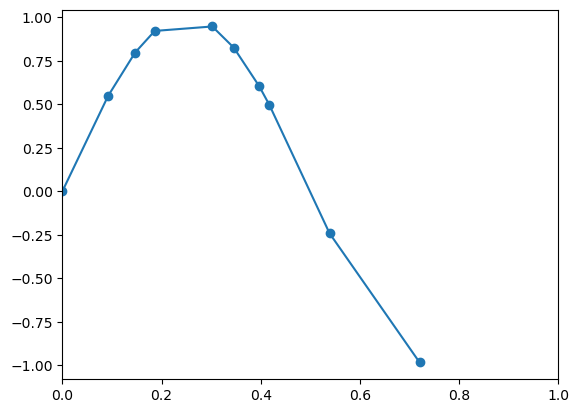

In [100]:
import os.path
import math
# Read in data from a file.  Download this from the BrightSpace  before you start.  
# If you forget to do this, the cell will generate the data for you, but small
# differences in random number generators might lead to different training data,
# which may make the lab harder to do.
filename = 'lab1_data.csv'

# If data doesn't exist, generate it
if not os.path.exists(filename):
    np.random.seed(1)
    train_x = np.sort(np.random.rand(10)) # 10 points, uniformly distributed between 0 and 1
    train_y = [math.sin(x * (2 * math.pi)) + 0.0 * np.random.randn() for x in train_x]
    data = np.transpose([train_x,train_y])
    np.savetxt(filename,data)

# Read in data from a file.  
data = np.loadtxt(filename)
train_x = np.asarray(data[:,0]).reshape((-1,1)) # First column of the data
train_y = np.asarray(data[:,1]).reshape((-1,1)) # Second column of the data
plt.xlim(0,1)
plt.plot(train_x, train_y,'o-')

Predictions with different kernels


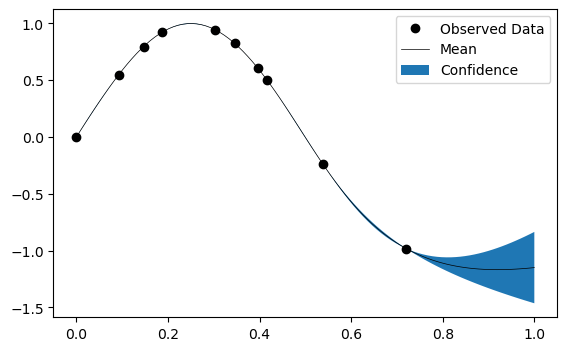

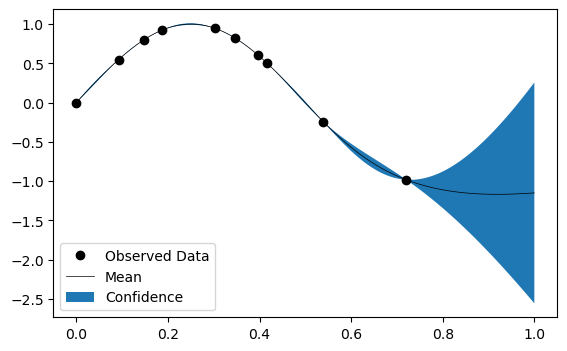

In [101]:

 # Once you have your predict function written, you can run the following code to plot your p
 # (the posterior mean), 95% Bayesian credible intervals (posterior mean +/- 1.96 * posterior
 # and the data
mean0 = lambda x : 0.0
def plot_prediction(mean:callable = mean0, kernel:Kernel = Matern(length_scale=L,nu=2.5)):
    m = []
    lb = []
    ub = []
    x = np.linspace(0,1,100)
    for test_x in x:
        mod_test_x = np.array(test_x).reshape((1,-1))
        pred_mean, pred_var = fit_predict(mod_test_x,train_x,train_y,mean,kernel)
        m.append(pred_mean.ravel())
       
        # Calculate the posterior standard deviation
        if pred_var<0:
            print('Posterior variance is negative ({:e}) at x={}, rounding up to 0')
            pred_var = 0
        
        s = np.sqrt(pred_var).ravel()[0] 
        lb.append((pred_mean.ravel()[0]-1.96*s))
        ub.append((pred_mean.ravel()[0]+1.96*s))

    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.plot(train_x,train_y,'ko')
    ax.plot(x,np.asarray(m).reshape((-1,1)),'k',linewidth=0.5)
    ax.fill_between(x,np.asarray(lb).ravel(),np.asarray(ub).ravel())
    ax.legend(['Observed Data', 'Mean', 'Confidence'])

    plt.show()

# NOTE: You can change the kernel here to see how it affects the prediction   
# You can change the kernel parameters to get different kinds of fits.
# Here, we are increasing the value of alpha0 from the default of 1.
kern_1 = CustomMaternKernel(length_scale=1.0,nu=2.5, alpha_0=1.0)
kern_2 = CustomMaternKernel(length_scale=0.05,nu=2.5, alpha_0=1.0)
kern_3 = CustomMaternKernel(length_scale=0.05,nu=2.5, alpha_0=20.0)
kern_4 = CustomMaternKernel(length_scale=1.0,nu=2.5, alpha_0=20.0)



# Plot the prediction
print("Predictions with different kernels")
# You can change the kernel parameters to get different kinds of fits.
# Here, we are increasing the value of alpha0 from the default of 1.
plot_prediction(mean = lambda x : -0.5, kernel = CustomMaternKernel(alpha_0=1,length_scale=1.0))
plot_prediction(mean = lambda x : -0.5, kernel = CustomMaternKernel(alpha_0=20.0, length_scale=1.0))




### Exercise #4: Simulating Paths from Posterior
You can also use your code to simulate sample paths from a Gaussian process posterior with a given mean and kernel function. To do this, fill in the gaps in the following code. This will help show how different mean functions, kernels, and their hyperparameters influence the kinds of functions that are likely under the prior. This is important for choosing what mean function and kernel to use in an application.

1) Simulate from left to right (`i=0` up to `m-1`), storing the value of `f(x[i]) in y[i]` . For our first point `(i=0)`, simulate from the prior, whose mean is the mean function evaluated at `x[0]` , and variance is the kernel function evaluated with both inputs at `x[0]` . Use np.random.normal for the normal distribution. Remember that it takes the standard devation as input, not the variance. https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html (https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html)
2) For the other m-1 points, get the posterior distribution at the point `x[i+1]` in our input space given the observations we have simulated so far ( x and y , 0 through i, inclusive). Use your predict function to get its mean and variance

In [121]:
def simulate_from_prior(mean=mean0, kernel=CustomMaternKernel(nu=2.5,length_scale=1.0,alpha_0=1.0), m=20):
   x = np.linspace(0,1,m)
   y = np.zeros(m)

   y[0] = np.random.normal(mean(x[0]), np.sqrt(kernel(np.asarray(x[0]).reshape((-1,1)),
                                                      np.asarray(x[0]).reshape((-1,1)))))
   ##### TODO:  Enter your code here:
   
   for i in range(m-1):
     new_mean,new_var = fit_predict(x[i+1],x[0:i+1],y[0:i+1],mean,kernel)
     y[i+1] = np.random.normal(new_mean,np.sqrt(new_var))

    ### END OF CODE INPUT ###
   return (x,y)

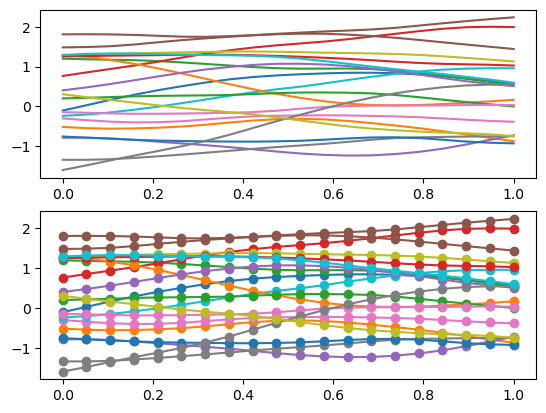

In [122]:

mean0 = lambda x : 0.0
# Using this, we can simulate many different sample paths from the posterior

def simulate_many_from_prior(mean=mean0, kernel=CustomMaternKernel(nu=2.5,length_scale=1.0,alpha_0=1.0), n=20, m=20):
   fig, ax = plt.subplots(2)
   for i in range(n):
     x,y = simulate_from_prior(mean,kernel,m)
     ax[0].plot(x,y)
     # The second figure shows the predicted value at each discretized point
     ax[1].plot(x,y, '-o')

simulate_many_from_prior()

## Exercise 5:
Play around with the parameters of the constant mean and matern kernel to understand how they influence the predictions and the simulated sample paths. In the following code, copied from above, we see 3 parameters: the mean of the constant mean, and the `alpha_0`, `length_scale` (which is a scalar when we have 1-dimensional x), and `nu`. With the implementation before, you could also use other types of kernels currently implemented within the `scikit-learn` framework.